# MLP avgGRM Nested CV vs Ridge and BPCRR

This notebook compares the standard `mlp_avggrm_weighted_results.json` run, plus the new `smart5` and `smart3` variants, against the 16-island ridge and BPCRR result files used in `visualize_bpcrr_inla.ipynb` for `body_mass`.

Notes:
- The MLP JSON stores one winning configuration per outer fold, not the full Optuna trial history.
- The "favoured" plots therefore summarize the settings selected by the winning trial in each outer fold.
- The ridge/BPCRR comparison figures below use the same 16-island leave-one-island-out style CSV outputs that feed the earlier BPCRR visualization notebook.
- The fold-preference plots near the bottom still summarize the original weighted MLP run unless expanded later.


In [1]:
from pathlib import Path
import sys

from IPython.display import display

NOTEBOOK_DIR = Path.cwd().resolve()
PROJECT_ROOT = next(
    (
        candidate
        for candidate in [NOTEBOOK_DIR, *NOTEBOOK_DIR.parents]
        if (candidate / "src").exists() and (candidate / "outputs").exists()
    ),
    NOTEBOOK_DIR,
)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.mlp_avggrm_viz_report import (
    build_full_baseline_comparison,
    build_full_baseline_summary,
    build_full_heatmap_df,
    build_full_winner_counts,
    build_model_summary,
    build_scheme_summary,
    build_winner_table,
    build_topk_comparison,
    build_topk_summary,
    plot_full_baseline_comparison,
    plot_full_baseline_heatmap_and_winners,
    plot_mlp_preference_grid,
    plot_mlp_selection_summary,
    plot_topk_comparison,
    prepare_report_data,
)


report = prepare_report_data(PROJECT_ROOT)


In [2]:
display(build_model_summary(report).round(3))
print("Reference comparisons below use the same 16-island ridge/BPCRR CSVs as visualize_bpcrr_inla.ipynb.")
print()
print(f"Shared islands for the full-source baseline comparison: {len(report['full_baseline_islands'])}")
print(", ".join(report["island_name_map"].get(i, str(i)) for i in report["full_baseline_islands"]))
print()
print(f"Shared islands for the top-k comparison at k={report['topk_value']}: {len(report['topk_islands'])}")
print(", ".join(report["island_name_map"].get(i, str(i)) for i in report["topk_islands"]))
print()
print("The island names above line up with the 16-island reference outputs from the earlier notebook.")


,comparison_group,label,n_islands,mean_corr,median_corr,std_corr
0,MLP weighted full,MLP avgGRM weighted,16,0.169,0.166,0.084
1,MLP weighted full (smart inner top-5),MLP avgGRM weighted (smart 5 inner islands),16,0.164,0.151,0.089
2,MLP weighted full (smart inner top-3),MLP avgGRM weighted (smart 3 inner islands),16,0.134,0.114,0.125
3,Full baselines (16 islands),BPCRR | full_source_unweighted,16,0.180,0.177,0.097
4,Full baselines (16 islands),Ridge (avgGRM) | full_source_unweighted,16,0.167,0.147,0.126
5,Full baselines (16 islands),Ridge (PCA) | full_source_unweighted,16,0.167,0.147,0.126
6,"Top-k (k=1500, 16 islands)",BPCRR | bpcrr_topk_avggrm (k=1500),16,0.194,0.180,0.092
7,"Top-k (k=1500, 16 islands)",Ridge (PCA) | pca_source_topk (k=1500),16,0.179,0.166,0.095
8,"Top-k (k=1500, 16 islands)",Ridge (avgGRM) | avggrm_topk (k=1500),16,0.166,0.154,0.092
9,"Top-k (k=1500, 16 islands)",BPCRR | bpcrr_topk_pc_distance (k=1500),16,0.158,0.139,0.122


Reference comparisons below use the same 16-island ridge/BPCRR CSVs as visualize_bpcrr_inla.ipynb.

Shared islands for the full-source baseline comparison: 16
Nesøy, Myken, Træna, Selvær, Gjerøy, Hestmannøy, Indre Kvarøy, Onøy og Lurøy, Lovund, Sleneset, Aldra, Southern 1, Southern 2, Southern 3, Southern 4, Southern 5

Shared islands for the top-k comparison at k=1500: 16
Nesøy, Myken, Træna, Selvær, Gjerøy, Hestmannøy, Indre Kvarøy, Onøy og Lurøy, Lovund, Sleneset, Aldra, Southern 1, Southern 2, Southern 3, Southern 4, Southern 5

The island names above line up with the 16-island reference outputs from the earlier notebook.


,model_label,mean_corr,median_corr,std_corr,n
0,BPCRR | full_source_unweighted,0.180,0.177,0.097,16
1,MLP avgGRM weighted,0.169,0.166,0.084,16
2,Ridge (avgGRM) | full_source_unweighted,0.167,0.147,0.126,16
3,Ridge (PCA) | full_source_unweighted,0.167,0.147,0.126,16
4,MLP avgGRM weighted (smart 5 inner islands),0.164,0.151,0.089,16
5,MLP avgGRM weighted (smart 3 inner islands),0.134,0.114,0.125,16


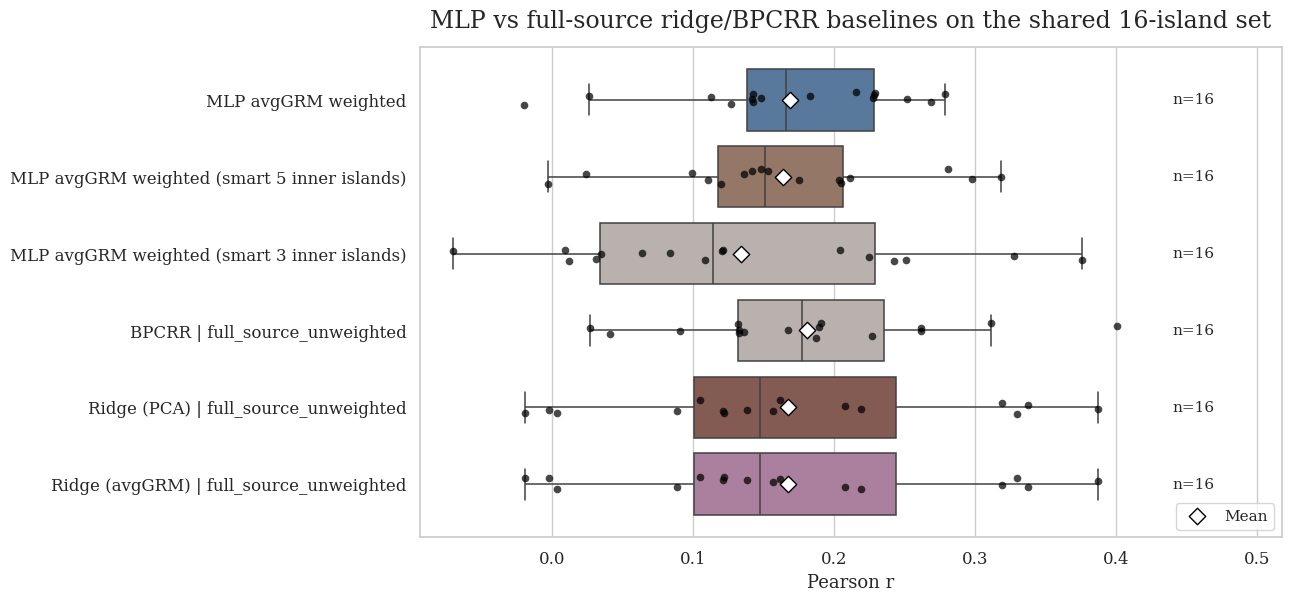

(<Figure size 1280x590 with 1 Axes>,
 <Axes: title={'center': 'MLP vs full-source ridge/BPCRR baselines on the shared 16-island set'}, xlabel='Pearson r'>)

In [3]:
display(
    build_full_baseline_summary(report).round(3)
)
plot_full_baseline_comparison(report)


,model_label,mean_corr,median_corr,std_corr,n
0,BPCRR | bpcrr_topk_avggrm (k=1500),0.194,0.180,0.092,16
1,Ridge (PCA) | pca_source_topk (k=1500),0.179,0.166,0.095,16
2,MLP avgGRM weighted,0.169,0.166,0.084,16
3,Ridge (avgGRM) | avggrm_topk (k=1500),0.166,0.154,0.092,16
4,MLP avgGRM weighted (smart 5 inner islands),0.164,0.151,0.089,16
5,BPCRR | bpcrr_topk_pc_distance (k=1500),0.158,0.139,0.122,16
6,Ridge (PEV) | pevmean_ga (k=1500),0.157,0.157,0.102,16
7,MLP avgGRM weighted (smart 3 inner islands),0.134,0.114,0.125,16


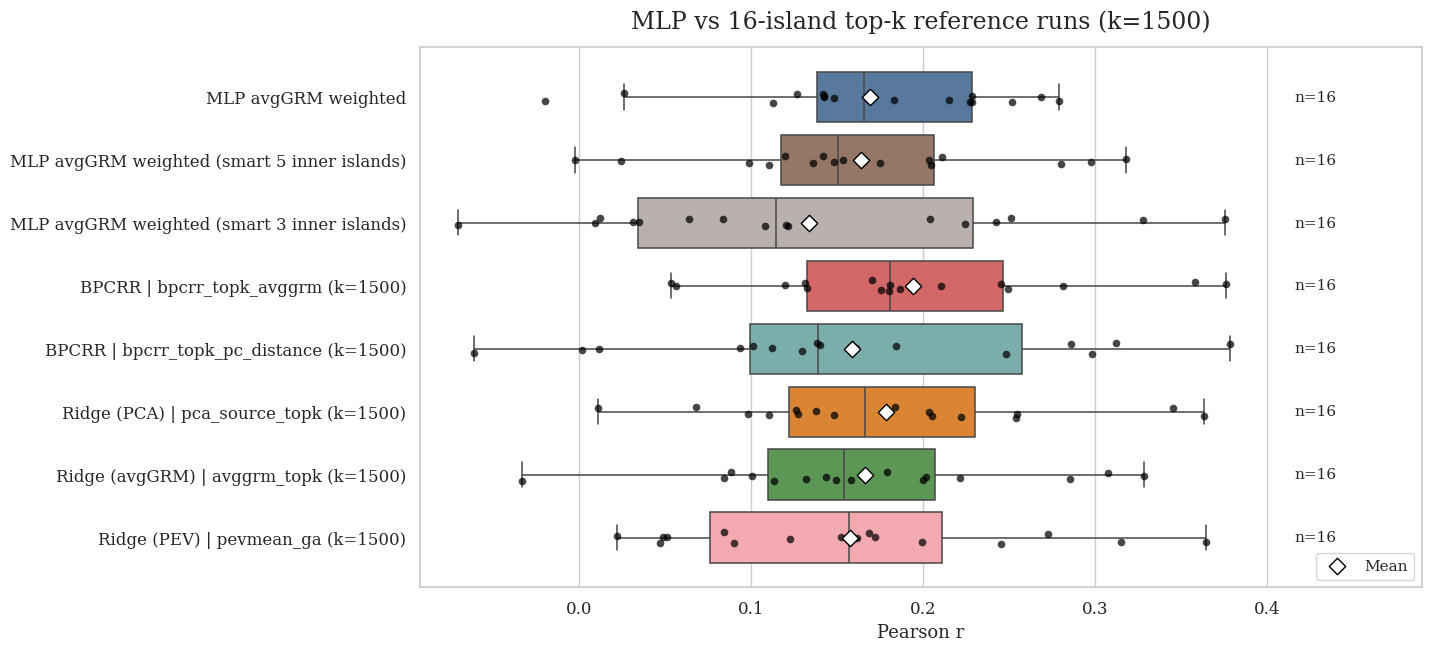

(<Figure size 1420x640 with 1 Axes>,
 <Axes: title={'center': 'MLP vs 16-island top-k reference runs (k=1500)'}, xlabel='Pearson r'>)

In [4]:
display(
    build_topk_summary(report).round(3)
)
plot_topk_comparison(report)


model_label,BPCRR | full_source_unweighted,MLP avgGRM weighted,MLP avgGRM weighted (smart 3 inner islands),MLP avgGRM weighted (smart 5 inner islands),Ridge (PCA) | full_source_unweighted,Ridge (avgGRM) | full_source_unweighted
Nesøy,0.311,0.229,0.120,0.136,0.208,0.208
Myken,0.167,0.268,0.328,0.298,0.337,0.337
Træna,0.261,0.183,0.225,0.141,0.156,0.156
Selvær,0.189,0.228,0.251,0.203,0.219,0.219
Gjerøy,0.091,0.112,0.108,0.148,0.088,0.088
Hestmannøy,0.132,0.142,0.121,0.153,0.138,0.138
Indre Kvarøy,0.262,0.227,0.242,0.205,0.319,0.319
Onøy og Lurøy,0.227,-0.020,0.009,-0.003,-0.003,-0.003
Lovund,0.400,0.279,0.376,0.318,0.387,0.387
Sleneset,0.187,0.143,0.064,0.120,0.162,0.162


,model_label,wins
0,MLP avgGRM weighted,2
1,MLP avgGRM weighted (smart 5 inner islands),3
2,MLP avgGRM weighted (smart 3 inner islands),1
3,BPCRR | full_source_unweighted,7
4,Ridge (PCA) | full_source_unweighted,3
5,Ridge (avgGRM) | full_source_unweighted,0


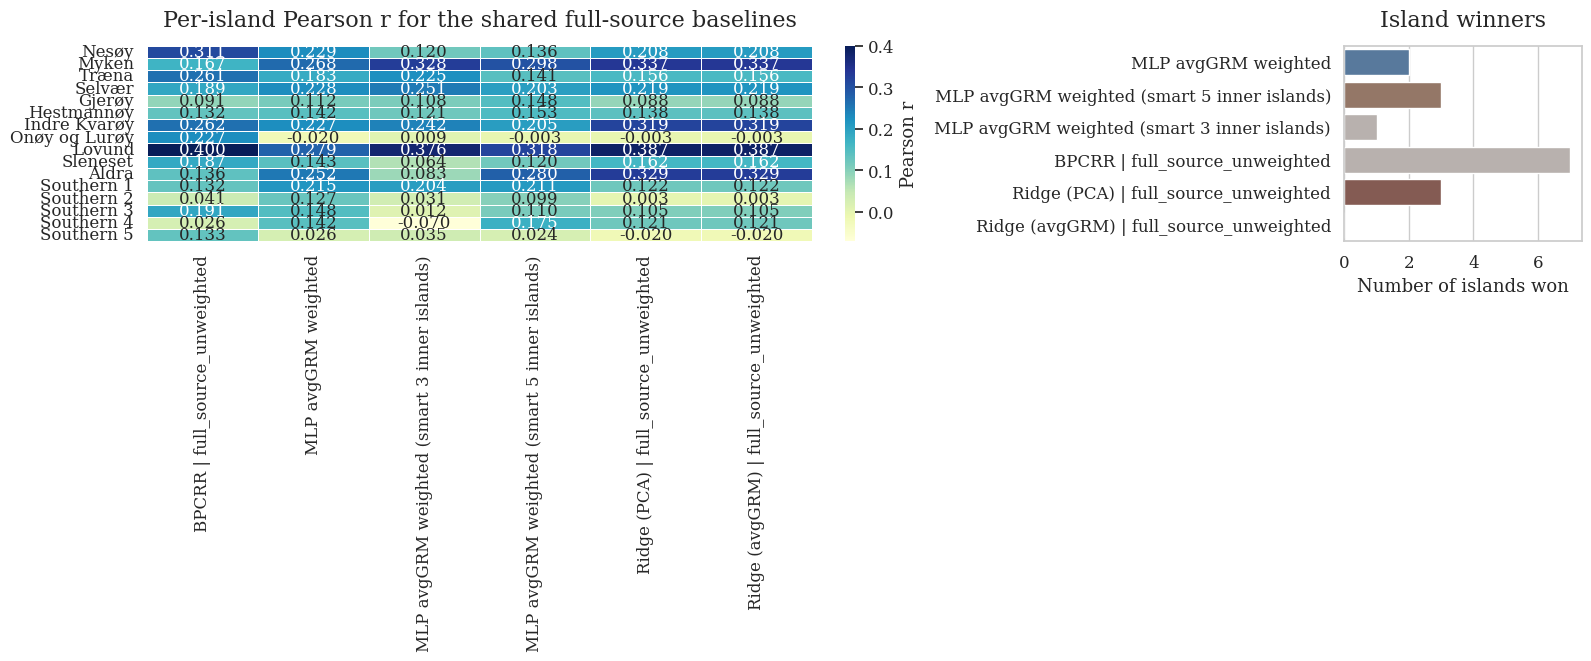

(<Figure size 1580x650 with 3 Axes>,
 array([<Axes: title={'center': 'Per-island Pearson r for the shared full-source baselines'}>,
        <Axes: title={'center': 'Island winners'}, xlabel='Number of islands won'>],
       dtype=object))

In [5]:
display(build_full_heatmap_df(report).round(3))
display(build_full_winner_counts(report))
plot_full_baseline_heatmap_and_winners(report)


## Winning-Fold Preferences

The figures below summarize the settings chosen by the winning trial in each outer fold. They are descriptive summaries of the selected fold-level winners, not a full Optuna trial-history analysis.


,weight_scheme,count,mean_outer_r,median_outer_r
0,minmax,7,0.150,0.142
1,exponential,4,0.201,0.197
2,top-heavy,3,0.161,0.228
3,linear,2,0.182,0.182


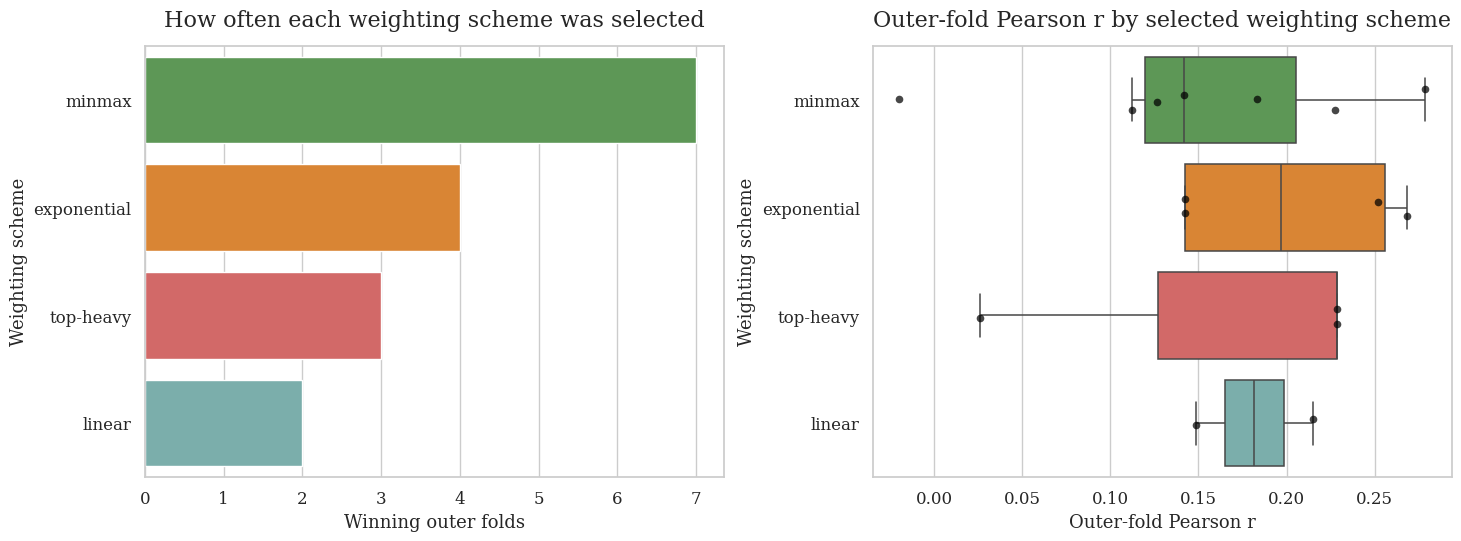

(<Figure size 1450x530 with 2 Axes>,
 array([<Axes: title={'center': 'How often each weighting scheme was selected'}, xlabel='Winning outer folds', ylabel='Weighting scheme'>,
        <Axes: title={'center': 'Outer-fold Pearson r by selected weighting scheme'}, xlabel='Outer-fold Pearson r', ylabel='Weighting scheme'>],
       dtype=object))

In [6]:
display(build_scheme_summary(report).round(3))
plot_mlp_selection_summary(report)


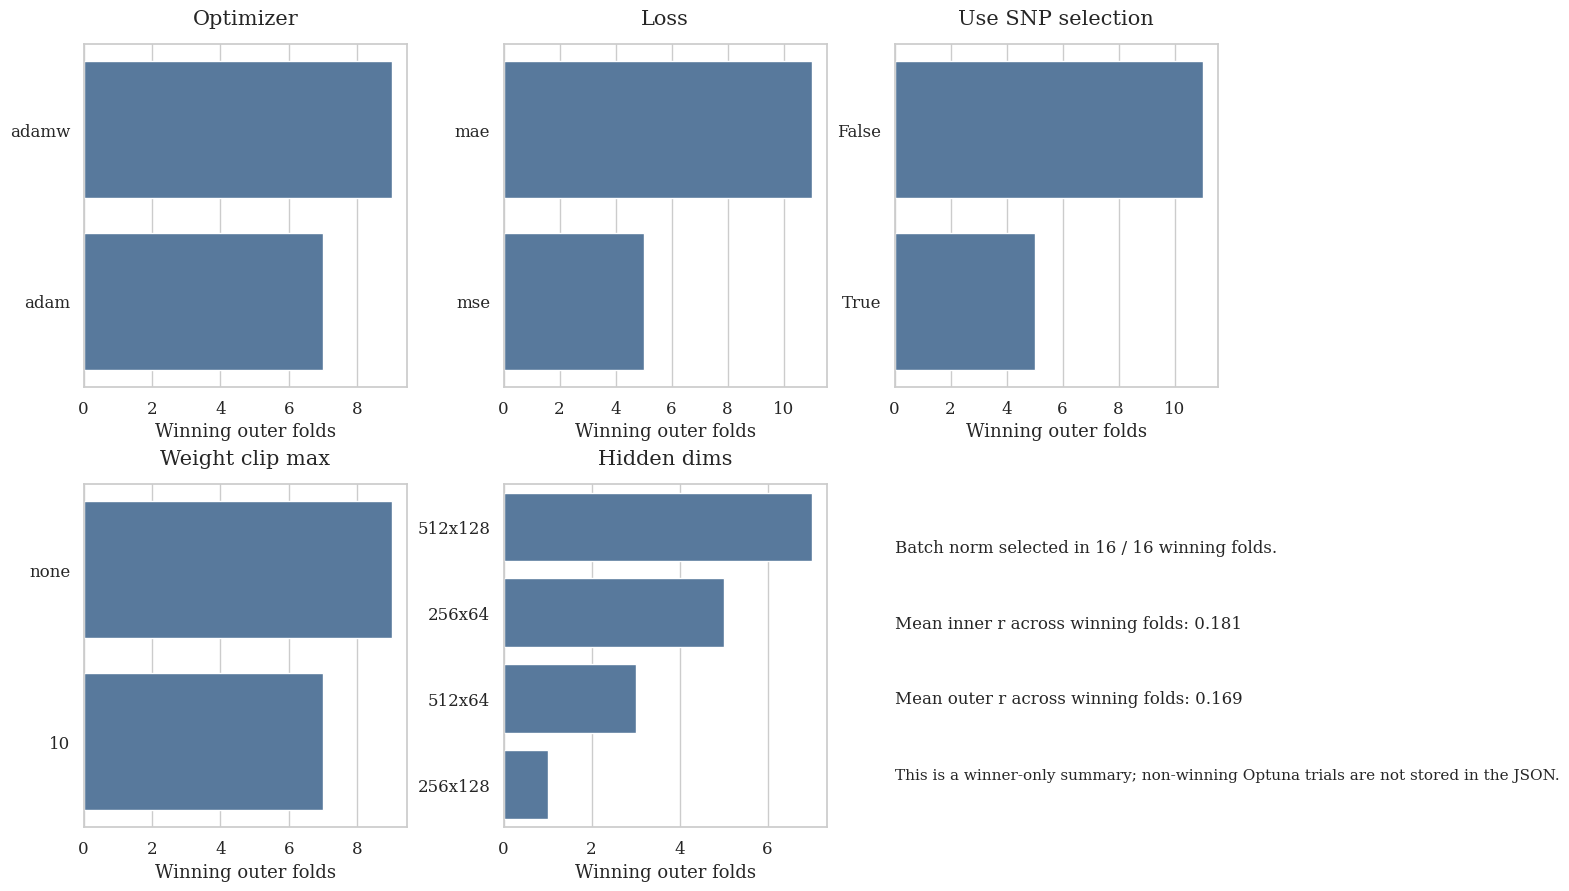

,fold,target_island_name,corr,mean_inner_r,weight_scheme,weighting_detail,optimizer,loss,use_snp_selection_label,hidden_dims,epochs,num_snps
0,1,Nesøy,0.229,0.179,top-heavy,"top_frac=0.07, low=0.92, high=1.35",adamw,mae,True,512x128,232,43628.0
1,2,Myken,0.268,0.179,exponential,beta=3.54,adamw,mae,False,512x128,140,NaN
2,3,Træna,0.183,0.185,minmax,"eps=0.193, clip=10",adamw,mse,False,512x64,134,NaN
3,4,Selvær,0.228,0.180,top-heavy,"top_frac=0.07, low=0.95, high=1.62",adam,mae,False,512x128,55,NaN
4,5,Gjerøy,0.112,0.177,minmax,"eps=0.077, clip=10",adam,mse,True,256x64,215,36890.0
5,6,Hestmannøy,0.142,0.168,exponential,beta=7.87,adamw,mae,False,256x64,65,NaN
6,7,Indre Kvarøy,0.227,0.179,minmax,"eps=0.057, clip=10",adam,mse,True,256x128,153,7294.0
7,8,Onøy og Lurøy,-0.020,0.205,minmax,"eps=0.087, clip=none",adam,mae,False,256x64,243,NaN
8,9,Lovund,0.279,0.164,minmax,"eps=0.196, clip=10",adamw,mse,False,512x128,57,NaN
9,10,Sleneset,0.143,0.179,exponential,beta=7.46,adamw,mae,False,256x64,52,NaN


In [7]:
plot_mlp_preference_grid(report)
display(build_winner_table(report).round(3))
